The [Street View House Numbers Dataset](https://www.openml.org/d/41081) contains 32-by-32 RGB images centered around a single digit of a house number appearing in Google Street View. Many of the images do contain some distractors at the sides. Your goal is to build a model that recognizes the correct digit. In detail, you need to do the following tasks:
1. Images come from real-world street scenes and include noise, distractors, and varying lighting. This is a multi-class classification problem with 10 output classes. Start with simple models like Logistic Regression using flattened image inputs.
2. Extend to Multi-Layer Perceptrons (MLP) to capture non-linear patterns.
3. Evaluate why these models fail due to lack of spatial feature extraction.
4. Develop Convolutional Neural Networks (CNNs) to capture spatial structure.
5. Apply preprocessing such as normalization and optional data augmentation.
6. Train using cross-entropy loss and evaluate with accuracy and confusion matrix.
7. Compare models and demonstrate performance improvements from simple to advanced architectures.

## Basic data loading

In [1]:
!pip install --quiet openml 


In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load SVHN from OpenML (dataset id 41081)
dataset = openml.datasets.get_dataset(41081)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
X = np.asarray(X, dtype=np.float64)
y = np.asarray(y, dtype=np.int64)

print(f"X shape: {X.shape}")
print(f"y range: {y.min()} – {y.max()}, unique classes: {len(np.unique(y))}")

X shape: (99289, 3072)
y range: 1 – 10, unique classes: 10


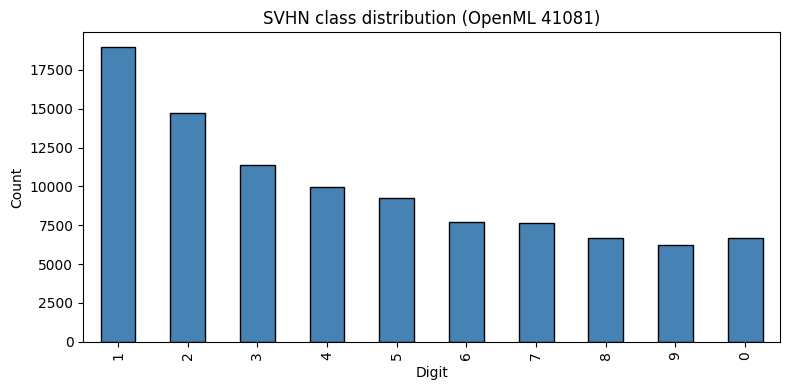

In [4]:
# Display labels: OpenML uses 1–9 for digits 1–9 and 10 for digit 0
label_display = {i: str(i) if i < 10 else "0" for i in range(1, 11)}

# Class distribution
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = [label_display[i] for i in class_counts.index]
fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
ax.set_title("SVHN class distribution (OpenML 41081)")
plt.tight_layout()
plt.show()

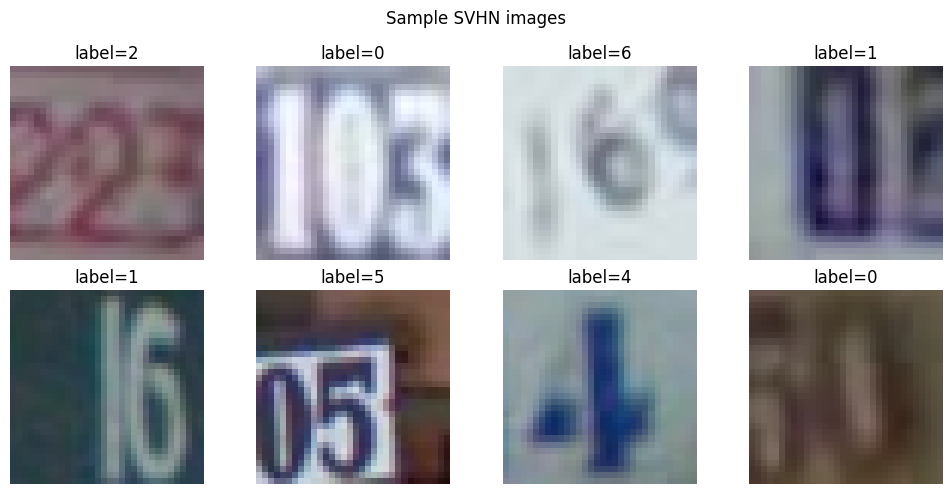

In [5]:
# Sample images (reshape flattened RGB row to 32×32×3)
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, idx in zip(axes.ravel(), np.random.default_rng(42).choice(len(X), 8, replace=False)):
    img = X[idx].reshape(32, 32, 3)
    img = np.clip(img, 0, 255).astype(np.uint8)
    ax.imshow(img)
    ax.set_title(f"label={label_display[y[idx]]}")
    ax.axis("off")
fig.suptitle("Sample SVHN images")
plt.tight_layout()
plt.show()

In [6]:
# Train/validation+test split (85% train+val, 15% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

## MLP

### Google Colab: enable GPU

1. **Runtime → Change runtime type**
2. Set **Hardware accelerator** to **GPU** (T4 is typical)
3. Click **Save**, then **Runtime → Restart session** (recommended after switching)
4. Run the cells below from the TensorFlow install through **GPU check**

If GPU is off, TensorFlow trains on CPU (slower but still works).

In [9]:
!pip install --quiet tensorflow

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- GPU setup (Colab: Runtime → Change runtime type → GPU, then restart session) ---
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("GPU memory growth:", e)
    print(f"TensorFlow {tf.__version__} — using GPU: {gpus[0].name}")
else:
    print(
        "No GPU detected. Training will use CPU.\n"
        "Colab: Runtime → Change runtime type → GPU → Save → Restart session, then re-run from here."
    )

# Optional: confirm a simple op runs on GPU
if gpus:
    with tf.device("/GPU:0"):
        _ = tf.reduce_sum(tf.random.normal((1000, 1000)))
    print("GPU test op: OK")


TensorFlow 2.20.0 — using GPU: /physical_device:GPU:0
GPU test op: OK


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.model_selection import train_test_split
y_train_tf = y_train - 1
y_test_tf = y_test - 1
# 15/85 of the train+val split gives a global 15% validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_tf, test_size=(15 / 85), random_state=42, stratify=y_train_tf
)

In [13]:
def build_MLP(hidden_units, drop_out = 0.3, num_classes = 10, learning_rate = 0.001, loss = 'sparse_categorical_crossentropy'):
    model = keras.Sequential([
        layers.Input(shape =(3072,)),
        layers.Dense(hidden_units[0], activation = 'relu'),
        layers.Dropout(drop_out),
        layers.Dense(hidden_units[0], activation = 'relu'),
        layers.Dropout(drop_out),
        layers.Dense(hidden_units[1],activation ='relu'),
        layers.Dropout(drop_out),
        layers.Dense(hidden_units[2],activation ='relu'),
        layers.Dropout(drop_out),
        layers.Dense(num_classes, activation = 'softmax'),
    ])
    model.compile(optimizer = keras.optimizers.Adam(learning_rate = learning_rate), loss = loss, metrics = ['accuracy'],)
    return model

In [14]:
import itertools
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping

param_grid = {
    "hidden_units": [[256, 128, 64], [512, 256, 128]],
    "drop_out": [0.3, 0.05],
    "learning_rate": [1e-3, 5e-4],
    "batch_size": [64, 128],
}

# Fewer epochs while searching; EarlyStopping saves time
search_epochs = 15
patience = 3

keys = list(param_grid.keys())
results = []

for values in itertools.product(*(param_grid[k] for k in keys)):
    params = dict(zip(keys, values))
    model = build_MLP(
        params["hidden_units"],
        drop_out=params["drop_out"],
        learning_rate=params["learning_rate"],
    )
    es = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )
    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=search_epochs,
        batch_size=params["batch_size"],
        callbacks=[es],
        verbose=0,
    )
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    row = {**params, "val_accuracy": val_acc, "val_loss": val_loss}
    results.append(row)
    print(row)

results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False)
best = results_df.iloc[0]
print("\nBest params:\n", best)

{'hidden_units': [256, 128], 'drop_out': 0.2, 'learning_rate': 0.001, 'batch_size': 64, 'val_accuracy': 0.8004783391952515, 'val_loss': 0.6553126573562622}
{'hidden_units': [256, 128], 'drop_out': 0.2, 'learning_rate': 0.001, 'batch_size': 128, 'val_accuracy': 0.8189828991889954, 'val_loss': 0.6143403053283691}
{'hidden_units': [256, 128], 'drop_out': 0.2, 'learning_rate': 0.0005, 'batch_size': 64, 'val_accuracy': 0.8221299052238464, 'val_loss': 0.6071779727935791}
{'hidden_units': [256, 128], 'drop_out': 0.2, 'learning_rate': 0.0005, 'batch_size': 128, 'val_accuracy': 0.8274168968200684, 'val_loss': 0.5918043255805969}
{'hidden_units': [256, 128], 'drop_out': 0.3, 'learning_rate': 0.001, 'batch_size': 64, 'val_accuracy': 0.7907854914665222, 'val_loss': 0.6862751841545105}
{'hidden_units': [256, 128], 'drop_out': 0.3, 'learning_rate': 0.001, 'batch_size': 128, 'val_accuracy': 0.8105488419532776, 'val_loss': 0.6539525985717773}
{'hidden_units': [256, 128], 'drop_out': 0.3, 'learning_rat

In [15]:
best_hidden = best["hidden_units"]  # if stored as list, use directly
final_model = build_MLP(
    best_hidden,
    drop_out=best["drop_out"],
    learning_rate=best["learning_rate"],
)
final_model.fit(
    X_train_scaled, y_train_tf,
    validation_data=(X_val, y_val),  # or merge tr+val and skip val
    epochs=30,
    batch_size=int(best["batch_size"]),
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
)

Epoch 1/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.5399 - loss: 1.4337 - val_accuracy: 0.7059 - val_loss: 0.9551
Epoch 2/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6896 - loss: 1.0004 - val_accuracy: 0.7494 - val_loss: 0.8327
Epoch 3/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7310 - loss: 0.8805 - val_accuracy: 0.7965 - val_loss: 0.6908
Epoch 4/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7497 - loss: 0.8141 - val_accuracy: 0.7972 - val_loss: 0.6699
Epoch 5/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7647 - loss: 0.7634 - val_accuracy: 0.8228 - val_loss: 0.5974
Epoch 6/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7786 - loss: 0.7224 - val_accuracy: 0.8291 - val_loss: 0.5802
Epoch 7/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7888 - loss: 0.6897 - val_accuracy: 0.8263 - val_loss: 0.5710
Epoch 8/30
621/621 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7947 - loss: 0.6698 - val_accuracy: 

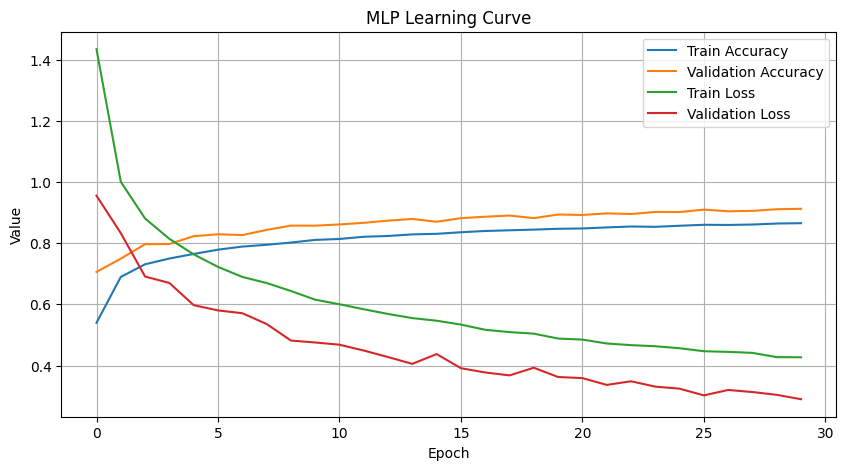

In [17]:
import matplotlib.pyplot as plt

# Plot the learning curves from the final_model training history
history = final_model.history

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('MLP Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_prob = final_model.predict(X_test_scaled, batch_size=256)
y_pred_tf = np.argmax(y_prob, axis=1)

test_acc = accuracy_score(y_test_tf, y_pred_tf) 
print(f"Test accuracy: {test_acc:.4f}")

# For report with digit names 0-9
target_names = [str(i) for i in range(10)]
print(classification_report(y_test_tf, y_pred_tf, target_names=target_names))

cm = confusion_matrix(y_test_tf, y_pred_tf)
# heatmap like your LR cell, tick_labels 0-9

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Test accuracy: 0.8568
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      3792
           1       0.88      0.90      0.89      2947
           2       0.81      0.84      0.82      2276
           3       0.89      0.88      0.88      1996
           4       0.84      0.81      0.83      1853
           5       0.85      0.79      0.82      1541
           6       0.86      0.87      0.86      1523
           7       0.84      0.75      0.79      1341
           8       0.84      0.80      0.82      1251
           9       0.86      0.85      0.85      1338

    accuracy                           0.86     19858
   macro avg       0.85      0.84      0.85     19858
weighted avg       0.86      0.86      0.86     19858



In [22]:
# There is no runtime.disconnect() in Colab.
# If you want to halt kernel execution or force disconnect, use:
# from google.colab import runtime
# runtime.shutdown()
# Or just stop execution via the UI.

# Optionally, raise SystemExit to stop cell execution:
raise SystemExit("Notebook run complete.")


SystemExit: Notebook run complete.

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
